# 

## 权重初始化：Xavier 与 Kaiming
目标：在不同激活下保持前向与反向的方差稳定，从而加速收敛、避免梯度消失或爆炸。

要点：
- Xavier(Glorot)：适用于 tanh/sigmoid/近似线性，Var≈2/(fan_in+fan_out)
- Kaiming(He)：适用于 ReLU/LeakyReLU，Var≈2/fan_in；LeakyReLU 需设置 a 与 nonlinearity
- ReLU 网络优先用 Kaiming；tanh/sigmoid 网络优先用 Xavier

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['SimHei','Microsoft YaHei','Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

Xavier(ReLU gain) 标准差: {'z1_std': 1.558380365371704, 'a1_std': 0.9106467366218567, 'z2_std': 1.8120837211608887, 'a2_std': 1.0307157039642334, 'z3_std': 2.3013973236083984}
Kaiming(ReLU) 标准差: {'z1_std': 1.4178147315979004, 'a1_std': 0.8268840909004211, 'z2_std': 1.401322603225708, 'a2_std': 0.8100786209106445, 'z3_std': 1.3878639936447144}


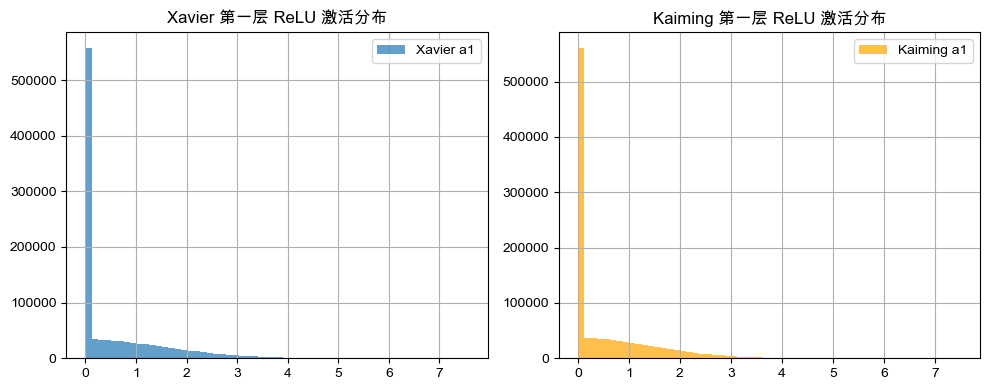

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim=784, h1=512, h2=256, out_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_dim)
    def forward(self, x):
        z1 = self.fc1(x); a1 = F.relu(z1)
        z2 = self.fc2(a1); a2 = F.relu(z2)
        z3 = self.fc3(a2)
        return (z1, a1, z2, a2, z3)

def init_xavier_for_relu(model):
    gain = nn.init.calculate_gain('relu')
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=gain)
            nn.init.zeros_(m.bias)

def init_kaiming_relu(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            nn.init.zeros_(m.bias)

@torch.no_grad()
def layer_stats(model, x, title):
    z1, a1, z2, a2, z3 = model(x)
    stats = {
        'z1_std': z1.std().item(), 'a1_std': a1.std().item(),
        'z2_std': z2.std().item(), 'a2_std': a2.std().item(),
        'z3_std': z3.std().item()
    }
    print(title, stats)
    return stats, (z1, a1, z2, a2, z3)

mx = MLP()
mk = MLP()
init_xavier_for_relu(mx)
init_kaiming_relu(mk)

x = torch.randn(2048, 784)
sx, acts_x = layer_stats(mx, x, 'Xavier(ReLU gain) 标准差:')
sk, acts_k = layer_stats(mk, x, 'Kaiming(ReLU) 标准差:')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(acts_x[1].flatten().numpy(), bins=60, alpha=0.7, label='Xavier a1')
plt.title('Xavier 第一层 ReLU 激活分布')
plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.hist(acts_k[1].flatten().numpy(), bins=60, alpha=0.7, color='orange', label='Kaiming a1')
plt.title('Kaiming 第一层 ReLU 激活分布')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## 批归一化（Batch Normalization）
核心：对 mini-batch 的特征按通道标准化为近似零均值、单位方差；再用可学习的缩放、平移恢复表达能力。训练期用批统计，推理期用滑动平均的全局统计。

要点：
- 常放在线性/卷积层之后、激活之前
- 线性用 BatchNorm1d，卷积用 BatchNorm2d（按通道统计）
- momentum 控制滑动平均；affine=True 时包含可学习的 γ、β

无BN 各层张量标准差: [0.5781120657920837, 0.3376460373401642, 0.23116059601306915, 0.1321272999048233, 0.09195676445960999]
有BN 各层张量标准差: [0.5767067670822144, 0.99998539686203, 0.5835992097854614, 0.40807661414146423, 0.9999568462371826, 0.5834854245185852, 0.39339593052864075]


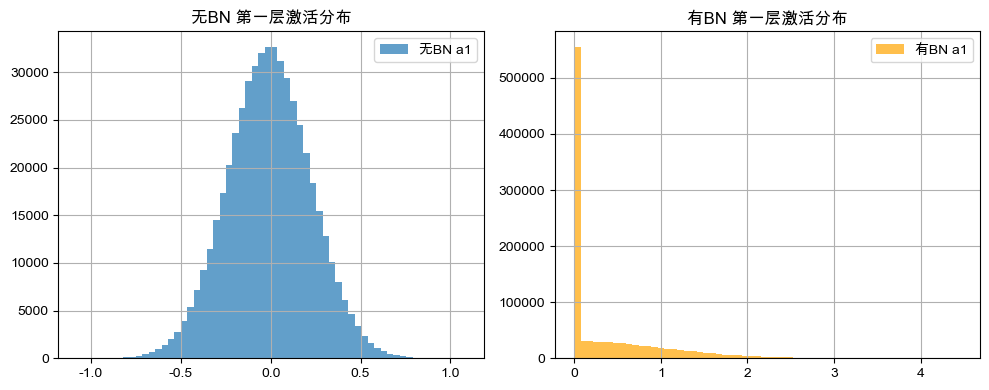

In [3]:
class MLPNoBN(nn.Module):
    def __init__(self, in_dim=784, h1=512, h2=256, out_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_dim)
    def forward(self, x):
        z1 = self.fc1(x); a1 = F.relu(z1)
        z2 = self.fc2(a1); a2 = F.relu(z2)
        z3 = self.fc3(a2)
        return (z1, a1, z2, a2, z3)

class MLPWithBN(nn.Module):
    def __init__(self, in_dim=784, h1=512, h2=256, out_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.fc3 = nn.Linear(h2, out_dim)
    def forward(self, x):
        z1 = self.fc1(x); n1 = self.bn1(z1); a1 = F.relu(n1)
        z2 = self.fc2(a1); n2 = self.bn2(z2); a2 = F.relu(n2)
        z3 = self.fc3(a2)
        return (z1, n1, a1, z2, n2, a2, z3)

@torch.no_grad()
def bn_stats(model, x, title):
    out = model(x)
    vals = [t.std().item() for t in out]
    print(title, vals)
    return out

m_nbn = MLPNoBN()
m_bn = MLPWithBN()
x = torch.randn(2048, 784)
o_nbn = bn_stats(m_nbn, x, '无BN 各层张量标准差:')
o_bn = bn_stats(m_bn, x, '有BN 各层张量标准差:')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(o_nbn[2].flatten().numpy(), bins=60, alpha=0.7, label='无BN a1')
plt.title('无BN 第一层激活分布')
plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.hist(o_bn[2].flatten().numpy(), bins=60, alpha=0.7, color='orange', label='有BN a1')
plt.title('有BN 第一层激活分布')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

无BN 前3个通道均值/标准差: [0.2502918839454651, 0.17499874532222748, 0.2517367899417877] [0.3347707986831665, 0.28525495529174805, 0.3676317036151886]
有BN 前3个通道均值/标准差: [0.3978468179702759, 0.39821577072143555, 0.3978811800479889] [0.5855687260627747, 0.5825875997543335, 0.5843674540519714]


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

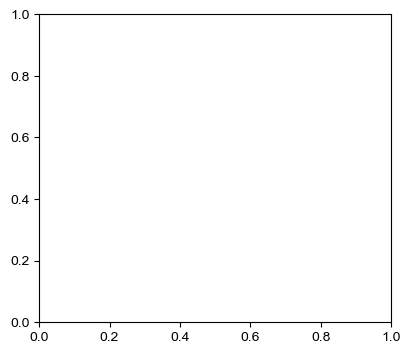

In [4]:
conv = nn.Conv2d(3, 16, 3, padding=1)
bn2d = nn.BatchNorm2d(16)
x = torch.randn(64, 3, 32, 32)
y1 = F.relu(conv(x))
y2 = F.relu(bn2d(conv(x)))
m1 = y1.mean(dim=(0,2,3))
s1 = y1.std(dim=(0,2,3))
m2 = y2.mean(dim=(0,2,3))
s2 = y2.std(dim=(0,2,3))
print('无BN 前3个通道均值/标准差:', m1[:3].tolist(), s1[:3].tolist())
print('有BN 前3个通道均值/标准差:', m2[:3].tolist(), s2[:3].tolist())
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y1[:,0].flatten().numpy(), bins=60, alpha=0.7, label='无BN ch0')
plt.title('Conv2d 无BN 激活分布(ch0)')
plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y2[:,0].flatten().numpy(), bins=60, alpha=0.7, color='orange', label='有BN ch0')
plt.title('Conv2d 有BN 激活分布(ch0)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()